# **PRÁCTICA TRANSFER LEARNING 2 - MOBILENET**

## 1. Prueba del modelo sin re-entrenamiento

In [1]:
import os
import numpy as np
import PIL.Image as Image
import keras
from keras.applications import MobileNetV2
from keras.models import Sequential

tam_imagen = 224

modelo1 = Sequential(
    [MobileNetV2(input_shape=(tam_imagen, tam_imagen, 3), weights="imagenet")]
)

# Suponiendo que tenemos las imágenes en la subcarpeta "prueba"
for nombre_archivo in os.listdir("/kaggle/input/imagenes-comidas-prueba/imagenes_comidas_prueba"):
    ruta_imagen = os.path.join("/kaggle/input/imagenes-comidas-prueba/imagenes_comidas_prueba", nombre_archivo)

    if ruta_imagen.endswith((".jpg", ".jpeg", ".png")):
        imagen = Image.open(ruta_imagen).resize((tam_imagen, tam_imagen))
        imagen = np.array(imagen) / 255
        resultado = modelo1.predict(imagen[np.newaxis, ...])
        codigo = np.argmax(resultado[0])

        fichero_etiquetas = keras.utils.get_file(
            "ImageNetLabels.txt",
            "https://storage.googleapis.com/download.tensorflow.org/data/ImageNetLabels.txt",
        )
        etiquetas = np.array(open(fichero_etiquetas).read().splitlines())

        print(nombre_archivo, ":", etiquetas[codigo])

14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
10484/10484 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
imagen_prueba_nachos.jpg : menu
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
imagen_prueba_guacamole.jpg : plate
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
imagen_prueba_donut.jpg : French loaf


## 2. Re-entrenando el modelo

In [2]:
from keras.layers import Dense, GlobalAveragePooling2D
from keras.layers import (
    Rescaling,
    RandomFlip,
    RandomRotation,
    RandomZoom,
    RandomTranslation,
)
from keras.utils import image_dataset_from_directory

batch_size = 32
carpeta_train = "/kaggle/input/imagenes-comidas/imagenes_comidas/train"
carpeta_test = "/kaggle/input/imagenes-comidas/imagenes_comidas/test"
clases = ["donuts", "guacamole", "nachos"]

In [3]:
# Preprocesamiento de imágenes de entrada
train_dataset = image_dataset_from_directory(
    carpeta_train,
    image_size=(tam_imagen, tam_imagen),
    batch_size=batch_size,
    labels="inferred",
    label_mode="categorical",
    class_names=clases,
)
test_dataset = image_dataset_from_directory(
    carpeta_test,
    image_size=(tam_imagen, tam_imagen),
    batch_size=batch_size,
    labels="inferred",
    label_mode="categorical",
    class_names=clases,
)

Found 2400 files belonging to 3 classes.
Found 600 files belonging to 3 classes.


In [4]:
# Etapas de aumento de datos y escalado
data_augmentation = Sequential(
    [
        RandomFlip("horizontal"),
        RandomRotation(0.2),
        RandomZoom(0.1),
        RandomTranslation(0.1, 0.1),
    ]
)

normalizacion = Rescaling(1.0 / 255)
train_dataset = train_dataset.map(lambda x, y: (data_augmentation(normalizacion(x)), y))
test_dataset = test_dataset.map(lambda x, y: (normalizacion(x), y))

In [5]:
# Construcción del modelo
extractor = MobileNetV2(
    input_shape=(tam_imagen, tam_imagen, 3), include_top=False, weights="imagenet"
)
extractor.trainable = False

modelo2 = Sequential(
    [
        extractor,
        GlobalAveragePooling2D(),
        Dense(128, activation="relu"),
        # Crearemos una red para identificar 3 tipos de comida
        Dense(3, activation="softmax"),
    ]
)

modelo2.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
modelo2.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [6]:
history = modelo2.fit(train_dataset, validation_data=test_dataset, epochs=5)

Epoch 1/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 53s 578ms/step - accuracy: 0.7341 - loss: 0.6223 - val_accuracy: 0.9183 - val_loss: 0.2685
Epoch 2/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 36s 484ms/step - accuracy: 0.8949 - loss: 0.2809 - val_accuracy: 0.9150 - val_loss: 0.2338
Epoch 3/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 37s 485ms/step - accuracy: 0.9042 - loss: 0.2696 - val_accuracy: 0.9267 - val_loss: 0.2262
Epoch 4/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 36s 481ms/step - accuracy: 0.9100 - loss: 0.2236 - val_accuracy: 0.9167 - val_loss: 0.2142
Epoch 5/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 36s 484ms/step - accuracy: 0.9114 - loss: 0.2074 - val_accuracy: 0.9183 - val_loss: 0.2102


---

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix

19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 167ms/step
              precision    recall  f1-score   support

      Donuts       0.35      0.36      0.36       200
   Guacamole       0.34      0.38      0.36       200
      Nachos       0.37      0.33      0.35       200

    accuracy                           0.36       600
   macro avg       0.36      0.35      0.35       600
weighted avg       0.36      0.35      0.35       600



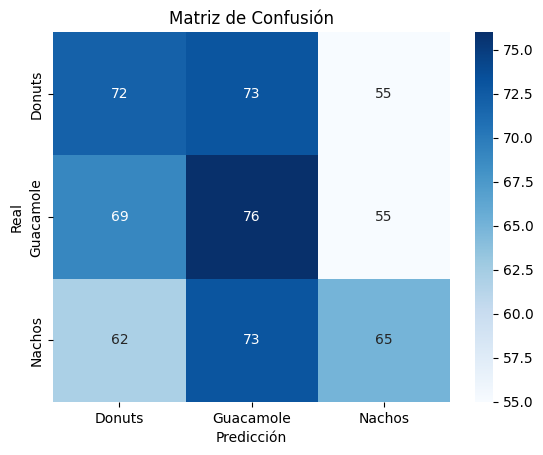

In [8]:
# Obtener etiquetas reales
y_true = np.concatenate([y for x, y in test_dataset], axis=0)

# Obtener predicciones del modelo
y_pred = modelo2.predict(test_dataset)

# Convertir las predicciones a etiquetas (clase con mayor probabilidad)
y_pred = np.argmax(y_pred, axis=1)  # Elegimos la clase con mayor probabilidad
y_true = np.argmax(y_true, axis=1)  # Convertimos y_true si está en one-hot encoding

# Definir nombres de las clases
target_names = ["Donuts", "Guacamole", "Nachos"]

# Reporte de clasificación
print(classification_report(y_true, y_pred, target_names=target_names))

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9288 - loss: 0.1907
Pérdida en test: 0.2102
Precisión en test: 0.9183


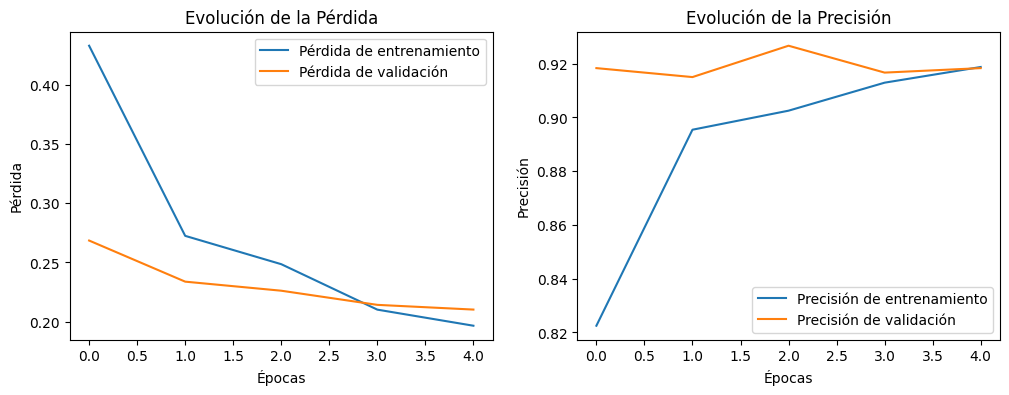

In [9]:
# Evaluación del modelo en el conjunto de test
loss, accuracy = modelo2.evaluate(test_dataset)

print(f"Pérdida en test: {loss:.4f}")
print(f"Precisión en test: {accuracy:.4f}")

# Extraer los valores del historial
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs_range = range(len(train_loss))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_loss, label='Pérdida de entrenamiento')
plt.plot(epochs_range, val_loss, label='Pérdida de validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.title('Evolución de la Pérdida')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_acc, label='Precisión de entrenamiento')
plt.plot(epochs_range, val_acc, label='Precisión de validación')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.title('Evolución de la Precisión')

plt.show()